<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fa9200;">Testing out Indicators across various Stocks to Validate
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------

# Import Packages

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import date, datetime
import os
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import statsmodels.formula.api as sm
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import yfinance as yf
from scipy.signal import argrelextrema
from collections import defaultdict
import sqlite3
import warnings
warnings.filterwarnings("ignore")
import Indicators
import Measurement
import Charts

# Grab Data for Ticker

In [2]:
tickers = Indicators.save_sp500_tickers()
ticker = tickers[0]
ticker = 'ALL'
#ticker = 'WDC'
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}
df = Indicators.get_ticker(ticker,500)
df

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker
0,2022-04-08 09:30:00-04:00,142.000000,142.399994,140.395004,140.524994,300631,0.0,0.0,2022-04-08 09:30:00,ALL
1,2022-04-08 10:30:00-04:00,140.529999,141.759995,140.509995,141.759995,197698,0.0,0.0,2022-04-08 10:30:00,ALL
2,2022-04-08 11:30:00-04:00,141.820007,142.000000,141.369995,141.490005,130027,0.0,0.0,2022-04-08 11:30:00,ALL
3,2022-04-08 12:30:00-04:00,141.490005,141.610001,141.210007,141.570007,119277,0.0,0.0,2022-04-08 12:30:00,ALL
4,2022-04-08 13:30:00-04:00,141.550003,141.845001,141.179993,141.720001,160068,0.0,0.0,2022-04-08 13:30:00,ALL
...,...,...,...,...,...,...,...,...,...,...
3486,2024-04-05 11:30:00-04:00,172.619995,173.460007,172.460007,173.339996,99623,0.0,0.0,2024-04-05 11:30:00,ALL
3487,2024-04-05 12:30:00-04:00,173.250000,173.460403,173.000000,173.050003,158623,0.0,0.0,2024-04-05 12:30:00,ALL
3488,2024-04-05 13:30:00-04:00,173.050003,173.160004,172.389999,172.389999,92050,0.0,0.0,2024-04-05 13:30:00,ALL
3489,2024-04-05 14:30:00-04:00,172.324997,172.744995,172.274994,172.544998,96242,0.0,0.0,2024-04-05 14:30:00,ALL


# Add SMA, Min/Max, Events

In [3]:
SMAs = [5,30,60,90]
smoothing = 7
window = 7

df = Indicators.get_sma(df,SMAs)
events_df = {}
minmax = Indicators.get_max_min(df, smoothing, window)
for event in events:
    events_df[event] = getattr(Indicators,event)(minmax)
#hs = Indicators.find_HS(minmax).reset_index(drop=True)
#invhs = Indicators.find_IHS(minmax).reset_index(drop=True)
#rw = Indicators.find_RW(minmax,.03).reset_index(drop=True)
#fw = Indicators.find_FW(minmax,.03).reset_index(drop=True)
df

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker,SMA5,SMA30,SMA60,SMA90
0,2022-04-08 09:30:00-04:00,142.000000,142.399994,140.395004,140.524994,300631,0.0,0.0,2022-04-08 09:30:00,ALL,NaN,NaN,NaN,NaN
1,2022-04-08 10:30:00-04:00,140.529999,141.759995,140.509995,141.759995,197698,0.0,0.0,2022-04-08 10:30:00,ALL,NaN,NaN,NaN,NaN
2,2022-04-08 11:30:00-04:00,141.820007,142.000000,141.369995,141.490005,130027,0.0,0.0,2022-04-08 11:30:00,ALL,NaN,NaN,NaN,NaN
3,2022-04-08 12:30:00-04:00,141.490005,141.610001,141.210007,141.570007,119277,0.0,0.0,2022-04-08 12:30:00,ALL,NaN,NaN,NaN,NaN
4,2022-04-08 13:30:00-04:00,141.550003,141.845001,141.179993,141.720001,160068,0.0,0.0,2022-04-08 13:30:00,ALL,141.413000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3486,2024-04-05 11:30:00-04:00,172.619995,173.460007,172.460007,173.339996,99623,0.0,0.0,2024-04-05 11:30:00,ALL,171.802997,172.442258,171.415003,168.446883
3487,2024-04-05 12:30:00-04:00,173.250000,173.460403,173.000000,173.050003,158623,0.0,0.0,2024-04-05 12:30:00,ALL,172.333997,172.467925,171.545337,168.560884
3488,2024-04-05 13:30:00-04:00,173.050003,173.160004,172.389999,172.389999,92050,0.0,0.0,2024-04-05 13:30:00,ALL,172.565997,172.472592,171.610737,168.671039
3489,2024-04-05 14:30:00-04:00,172.324997,172.744995,172.274994,172.544998,96242,0.0,0.0,2024-04-05 14:30:00,ALL,172.794998,172.484422,171.673820,168.777206


# Plot Data

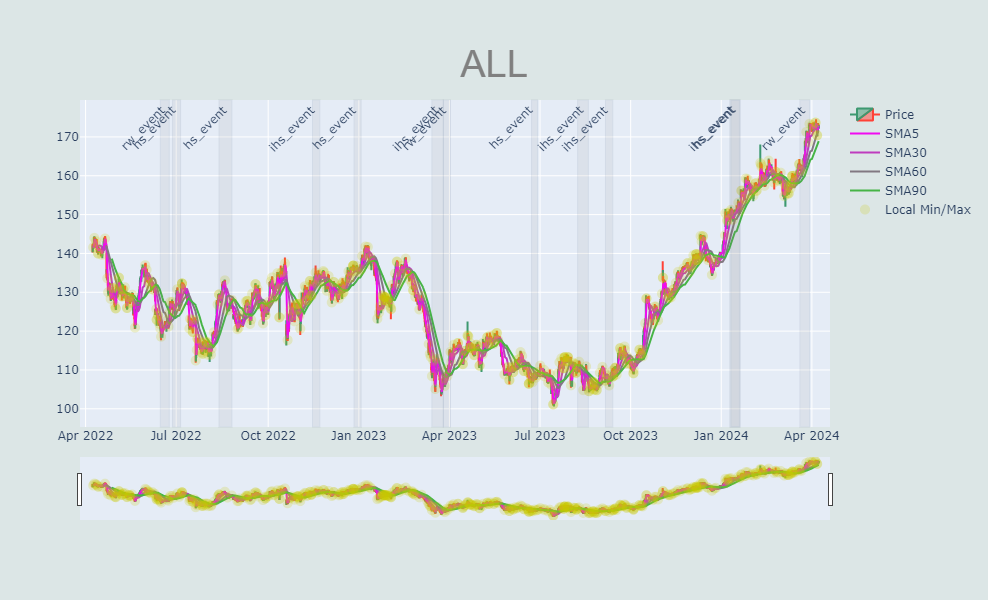

In [4]:
Charts.chart_all(df,events,events_df,SMAs,minmax)

# Zoom in on Specific Event

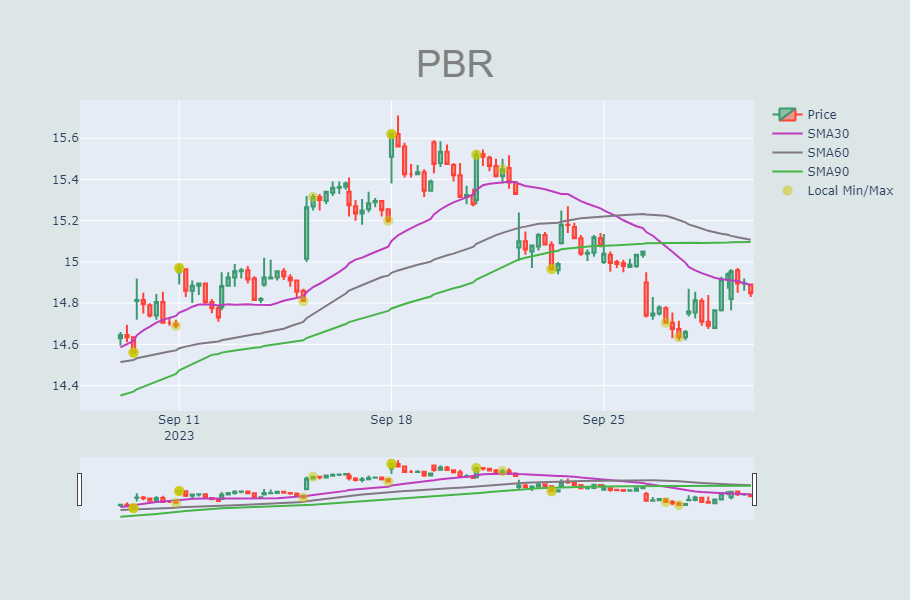

In [46]:
df2 = Indicators.main(ticker,500,SMAs,smoothing,window)
eventType = 'rw_event'
ID = list(df2[df2.date==df2[df2[eventType]==1].date.min()].index)[0]
chartdf = df2.iloc[ID-10:ID+95].copy()
minmax2 = minmax[(minmax.date>=chartdf.date.min())&(minmax.date<=chartdf.date.max())].copy()
fig = go.Figure()
fig = go.Figure(data=[go.Candlestick(x=chartdf['date'],
                open=chartdf['open'],
                high=chartdf['high'],
                low=chartdf['low'],
                close=chartdf['close'],
                name='Price')])
for n in SMAs:
    rgb = 'rgb({},{},{})'.format(250-n*2,n*2,250-n*2)
    fig.add_trace(go.Scatter(x=chartdf['date'],
                y=chartdf['SMA{}'.format(n)],
                mode='lines',
                name='SMA{}'.format(n),
                line=dict(color=rgb)))
fig.add_trace(go.Scatter(x=minmax2['date'],
                y=minmax2['close'],
                mode='markers',
                name='Local Min/Max',
                marker=dict(color='rgb(200,200,0)',
                            size=10,
                            opacity=0.5)
                        ))
fig.update_xaxes(
        rangeslider_visible=True,
        rangebreaks=[
            # NOTE: Below values are bound (not single values), ie. hide x to y
            dict(bounds=["sat", "mon"]),  # hide weekends, eg. hide sat to before mon
            dict(bounds=[16, 9.5], pattern="hour"),  # hide hours outside of 9.30am-4pm
            #dict(values=["2024-12-25", "2024-01-01","2024-01-15","2024-02-19"])  # hide holidays (Christmas and New Year's, etc)
        ]
    )
fig.update_layout(title={'text':ticker, 'xanchor':'center', 'yanchor':'top','x':0.5},
                height=600,
                title_font={"family":"arial","color":"gray","size":38},
                paper_bgcolor='rgb(220,230,230)'
                 )
fig.show()

# Build Inidcators and Group by Change During Event

In [5]:
M = 80
K = 500
window = 7
smoothing = 7
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}


df3 = Measurement.combine_events(tickers,events,SMAs,smoothing,window,M,K)
df3.reset_index(inplace=True,drop=True)
event = 'fw_event'
df3.groupby(['ticker',event + '_start_time',event + '_end_time']).agg({'volume':'size',event:'mean'}).reset_index().head(20)

BRK.B: No data found, symbol may be delisted
'DataFrame' object has no attribute 'Datetime'
BF.B: Period '500d' is invalid, must be one of ['1mo', '3mo', '6mo', 'ytd', '1y', '2y', '5y', '10y', 'max']
'DataFrame' object has no attribute 'Datetime'


,ticker,fw_event_start_time,fw_event_end_time,volume,fw_event
0,A,2022-04-12 09:30:00,2023-02-07 13:30:00,1489,0.0
1,A,2023-02-07 14:30:00,2023-02-21 11:30:00,61,1.0
2,A,2023-02-21 12:30:00,2023-09-13 10:30:00,983,0.0
3,A,2023-09-13 11:30:00,2023-09-21 15:30:00,47,1.0
4,A,2023-09-22 09:30:00,2024-04-09 13:30:00,954,0.0
5,AAL,2022-04-12 09:30:00,2022-05-03 13:30:00,103,0.0
6,AAL,2022-05-03 14:30:00,2022-05-12 13:30:00,49,1.0
7,AAL,2022-05-12 14:30:00,2023-07-26 15:30:00,2103,0.0
8,AAL,2023-07-27 09:30:00,2023-08-07 10:30:00,51,1.0
9,AAL,2023-08-07 11:30:00,2023-09-08 13:30:00,164,0.0


In [6]:
event = 'fw_event'
df3.groupby(['ticker',event + '_start_time',event + '_end_time']).agg({'volume':'size',event:'mean'}).reset_index().head(20)

,ticker,fw_event_start_time,fw_event_end_time,volume,fw_event
0,A,2022-04-12 09:30:00,2023-02-07 13:30:00,1489,0.0
1,A,2023-02-07 14:30:00,2023-02-21 11:30:00,61,1.0
2,A,2023-02-21 12:30:00,2023-09-13 10:30:00,983,0.0
3,A,2023-09-13 11:30:00,2023-09-21 15:30:00,47,1.0
4,A,2023-09-22 09:30:00,2024-04-09 13:30:00,954,0.0
5,AAL,2022-04-12 09:30:00,2022-05-03 13:30:00,103,0.0
6,AAL,2022-05-03 14:30:00,2022-05-12 13:30:00,49,1.0
7,AAL,2022-05-12 14:30:00,2023-07-26 15:30:00,2103,0.0
8,AAL,2023-07-27 09:30:00,2023-08-07 10:30:00,51,1.0
9,AAL,2023-08-07 11:30:00,2023-09-08 13:30:00,164,0.0


In [7]:
final4 = Measurement.get_totals(df3,events)
final4.reset_index(inplace=True)
#final4['50%-2'] = pd.Series(["{0:.2f}%".format(val * 100) for val in final4['50%-2']], index = final4.index)

eventSuccess = final4.groupby('event')['Indicator'].mean(). \
            reset_index(). \
            rename(columns={'Indicator':'event_success'})
stockSuccess = final4.groupby(['event','ticker']). \
            agg({'Indicator':'mean','after_event_observations':'sum'}). \
            reset_index(). \
            rename(columns={'Indicator':'stock_success','after_event_observations':'event_count'})
totalSuccess = eventSuccess.merge(stockSuccess, on = ['event'])
totalSuccess = totalSuccess[['event','ticker','event_count','event_success','stock_success']]

final4 = final4.merge(totalSuccess, on = ['event','ticker'])

final4

,index,ticker,event,event_observations,event_start_time,event_end_time,after_event_observations,after_event_mean,after_event_start_time,after_event_end_time,count,mean,min,median,max,Indicator,event_count,event_success,stock_success
0,0,A,rw_event,133.0,2022-07-15 15:30:00,2022-08-03 11:30:00,1.0,-0.045636,2022-08-03 11:30:00,2022-08-18 13:30:00,2062.0,-0.046289,-0.165649,-0.037882,0.034253,1,4.0,0.494797,1.0
1,1,A,rw_event,46.0,2023-04-04 12:30:00,2023-04-13 15:30:00,1.0,-0.095060,2023-04-13 15:30:00,2023-05-01 10:30:00,2062.0,-0.046289,-0.165649,-0.037882,0.034253,1,4.0,0.494797,1.0
2,2,A,rw_event,36.0,2023-10-31 14:30:00,2023-11-07 14:30:00,1.0,-0.050012,2023-11-07 14:30:00,2023-11-24 09:30:00,2062.0,-0.046289,-0.165649,-0.037882,0.034253,1,4.0,0.494797,1.0
3,3,A,rw_event,51.0,2023-12-11 10:30:00,2023-12-20 11:30:00,1.0,-0.088146,2023-12-20 11:30:00,2024-01-08 13:30:00,2062.0,-0.046289,-0.165649,-0.037882,0.034253,1,4.0,0.494797,1.0
4,4,AAL,rw_event,23.0,2023-05-26 09:30:00,2023-06-01 10:30:00,1.0,-0.010526,2023-06-01 10:30:00,2023-06-16 12:30:00,2286.0,-0.076640,-0.486318,-0.061844,0.037932,0,2.0,0.494797,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7596,2121,ZBRA,ihs_event,44.0,2022-12-19 13:30:00,2022-12-28 14:30:00,1.0,0.184229,2022-12-28 14:30:00,2023-01-17 09:30:00,2415.0,0.063878,-0.146742,0.053492,0.218779,1,1.0,0.496707,1.0
7597,2122,ZTS,ihs_event,53.0,2023-04-20 14:30:00,2023-05-02 10:30:00,1.0,0.055753,2023-05-02 10:30:00,2023-05-17 12:30:00,1930.0,0.046793,-0.009409,0.037547,0.266723,1,4.0,0.496707,0.5
7598,2123,ZTS,ihs_event,33.0,2023-09-14 12:30:00,2023-09-21 09:30:00,1.0,-0.005281,2023-09-21 09:30:00,2023-10-06 11:30:00,1930.0,0.046793,-0.009409,0.037547,0.266723,0,4.0,0.496707,0.5
7599,2124,ZTS,ihs_event,56.0,2023-11-22 09:30:00,2023-12-05 11:30:00,1.0,0.113034,2023-12-05 11:30:00,2023-12-20 13:30:00,1930.0,0.046793,-0.009409,0.037547,0.266723,1,4.0,0.496707,0.5


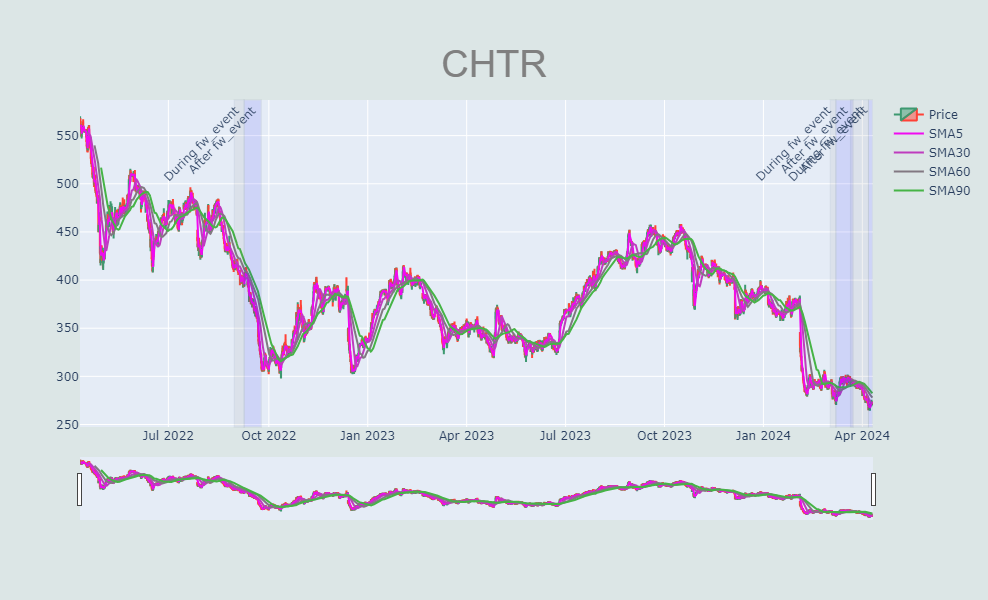

In [35]:
event = 'fw_event'
ticker = 'CHTR'
    
#Charts.chart_event(df3,event,ticker)
chart_event(df3,event,ticker)

In [29]:
from datetime import timedelta
final4[(abs(final4['after_event_mean']-final4['median']) > 0.03)&
      (final4['event_observations']> 10)&
      (pd.to_datetime(final4['after_event_end_time'])<(datetime.today()-timedelta(days=1)))].groupby('event')['median'].describe()

,count,mean,std,min,25%,50%,75%,max
event,,,,,,,,
fw_event,529.0,0.045041,0.013872,0.018781,0.035312,0.042265,0.053070,0.102418
hs_event,658.0,0.045908,0.013987,0.018512,0.036660,0.043437,0.053680,0.102418
ihs_event,736.0,0.045333,0.013687,0.018781,0.035528,0.042940,0.053343,0.090316
rw_event,628.0,-0.042185,0.014781,-0.093123,-0.050142,-0.039370,-0.031657,-0.015376


In [9]:
final4.sort_values(['event_end_time'],ascending=0).head(20)

,index,ticker,event,event_observations,event_start_time,event_end_time,after_event_observations,after_event_mean,after_event_start_time,after_event_end_time,count,mean,min,median,max,Indicator,event_count,event_success,stock_success
3887,520,DAL,hs_event,27.0,2024-04-02 10:30:00,2024-04-05 15:30:00,1.0,0.066992,2024-04-05 15:30:00,2024-04-09 13:30:00,2329.0,0.058717,-0.037935,0.053214,0.182030,1,5.0,0.472011,1.000000
4566,1199,LUV,hs_event,27.0,2024-04-02 09:30:00,2024-04-05 14:30:00,1.0,0.029809,2024-04-05 14:30:00,2024-04-09 13:30:00,1686.0,0.045190,-0.103819,0.031759,0.155969,0,7.0,0.472011,0.285714
4223,856,GPN,hs_event,27.0,2024-04-02 09:30:00,2024-04-05 14:30:00,1.0,0.026541,2024-04-05 14:30:00,2024-04-09 13:30:00,1790.0,0.055739,-0.032764,0.052621,0.174722,0,6.0,0.472011,0.500000
989,989,JNPR,rw_event,32.0,2024-04-01 11:30:00,2024-04-05 14:30:00,1.0,-0.005912,2024-04-05 14:30:00,2024-04-09 13:30:00,2108.0,-0.044826,-0.172073,-0.036035,0.017646,0,4.0,0.494797,0.250000
6529,1054,ISRG,ihs_event,19.0,2024-04-03 09:30:00,2024-04-05 13:30:00,1.0,0.040571,2024-04-05 13:30:00,2024-04-09 13:30:00,1829.0,0.054330,-0.085852,0.044224,0.280901,0,2.0,0.496707,0.500000
3880,513,CZR,hs_event,32.0,2024-04-01 10:30:00,2024-04-05 13:30:00,1.0,0.078899,2024-04-05 13:30:00,2024-04-09 13:30:00,2408.0,0.092801,-0.033730,0.079439,0.263949,0,1.0,0.472011,0.000000
3437,70,AES,hs_event,27.0,2024-04-01 15:30:00,2024-04-05 13:30:00,1.0,0.139308,2024-04-05 13:30:00,2024-04-09 13:30:00,2240.0,0.059543,-0.011316,0.049087,0.213822,1,5.0,0.472011,0.400000
5249,1882,TTWO,hs_event,38.0,2024-03-28 11:30:00,2024-04-05 13:30:00,1.0,0.027544,2024-04-05 13:30:00,2024-04-09 13:30:00,1838.0,0.061277,-0.013041,0.056483,0.197032,0,5.0,0.472011,0.800000
4248,881,HBAN,hs_event,22.0,2024-04-02 13:30:00,2024-04-05 13:30:00,1.0,0.045796,2024-04-05 13:30:00,2024-04-09 13:30:00,1888.0,0.056599,-0.020370,0.049682,0.166022,0,6.0,0.472011,0.000000
6327,852,GIS,ihs_event,34.0,2024-03-28 14:30:00,2024-04-05 12:30:00,1.0,0.017805,2024-04-05 12:30:00,2024-04-09 13:30:00,1743.0,0.029929,-0.026766,0.021411,0.124128,0,6.0,0.496707,0.375000


In [12]:
final[(final['event_observations']> 10)&
      (pd.to_datetime(final['after_event_end_time'])<(datetime.today()-timedelta(days=1)))].Indicator.describe()

count    1771.000000
mean        0.525692
std         0.499481
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Indicator, dtype: float64

0.28623333333333334